In [12]:
%pip install torch numpy pretty_midi matplotlib scikit-learn gdown

In [13]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected.")

Torch version: 2.8.0+cu126
CUDA available: True
GPU: Tesla T4


In [15]:
# Download processed dataset from Google Drive using gdown

import os
import numpy as np

# Make processed data directory
os.makedirs("data/processed", exist_ok=True)

# Google Drive file IDs (from your shared links)
FULL_ID = "1CtHDWKmGfZap8WpfN0Fnk2F_V17tqQHQ"
SPLITS_ID = "1gbCFRjc_EBND8tYP5CwiX6Z8a3JXt-il"

# Download the files
!gdown --id {FULL_ID} -O data/processed/full_sequences.npz
!gdown --id {SPLITS_ID} -O data/processed/splits_filelevel_indices.npz

print("Files in data/processed:", os.listdir("data/processed"))

# Load the datasets
dataset = np.load("data/processed/full_sequences.npz", allow_pickle=True)
splits = np.load("data/processed/splits_filelevel_indices.npz", allow_pickle=True)

X_ids = dataset["X"]
y_ids = dataset["y"]
file_indices = dataset["file_indices"]
vocab = dataset["vocab"]

train_idx = splits["train_idx"]
val_idx   = splits["val_idx"]
test_idx  = splits["test_idx"]

print("Loaded X shape:", X_ids.shape)
print("Loaded y shape:", y_ids.shape)
print("Train/Val/Test sizes:", len(train_idx), len(val_idx), len(test_idx))


/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1CtHDWKmGfZap8WpfN0Fnk2F_V17tqQHQ
From (redirected): https://drive.google.com/uc?id=1CtHDWKmGfZap8WpfN0Fnk2F_V17tqQHQ&confirm=t&uuid=6219585f-c5cb-4f9c-8a95-d8f37bed18d8
To: /content/data/processed/full_sequences.npz
100% 284M/284M [00:02<00:00, 115MB/s]  
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1gbCFRjc_EBND8tYP5CwiX6Z8a3JXt-il
To: /content/data/processed/splits_filelevel_indices.npz
100% 5.47M/5.47M [00:00<00:00, 29.5MB/s]
Files in data/processed: ['full_sequences.npz', 'split

In [16]:
import torch
from torch.utils.data import Dataset, DataLoader

# Make sure we’re on the right device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


class MusicSequenceDataset(Dataset):
    """
    Wraps X_ids and y_ids, but only exposes the rows given by index_array.
    Each __getitem__ returns (input_seq, target_token) as torch tensors.
    """
    def __init__(self, X_all, y_all, index_array):
        self.X_all = X_all
        self.y_all = y_all
        self.index_array = index_array  # e.g., train_idx, val_idx, test_idx

    def __len__(self):
        return len(self.index_array)

    def __getitem__(self, idx):
        real_idx = self.index_array[idx]
        x = self.X_all[real_idx]   # shape: (SEQ_LEN,)
        y = self.y_all[real_idx]   # scalar

        # Convert to torch tensors
        x = torch.tensor(x, dtype=torch.long)
        y = torch.tensor(y, dtype=torch.long)

        return x, y


# Hyperparameter: batch size
BATCH_SIZE = 128 

# Create Dataset objects
train_dataset = MusicSequenceDataset(X_ids, y_ids, train_idx)
val_dataset   = MusicSequenceDataset(X_ids, y_ids, val_idx)
test_dataset  = MusicSequenceDataset(X_ids, y_ids, test_idx)

print("Train dataset size:", len(train_dataset))
print("Val dataset size:  ", len(val_dataset))
print("Test dataset size: ", len(test_dataset))

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,   # shuffle for training
    drop_last=True  # makes batch sizes consistent
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

# Quick sanity check: get one batch
batch_x, batch_y = next(iter(train_loader))
print("One batch X shape:", batch_x.shape)  # expected: (BATCH_SIZE, SEQ_LEN)
print("One batch y shape:", batch_y.shape)  # expected: (BATCH_SIZE,)
print("X dtype:", batch_x.dtype, "| y dtype:", batch_y.dtype)


Using device: cuda
Train dataset size: 506185
Val dataset size:   86984
Test dataset size:  89949
One batch X shape: torch.Size([128, 50])
One batch y shape: torch.Size([128])
X dtype: torch.int64 | y dtype: torch.int64


In [19]:
import torch
import torch.nn as nn

# Infer vocab size and sequence length from loaded data
VOCAB_SIZE = vocab.shape[0]
SEQ_LEN = X_ids.shape[1]
print("VOCAB_SIZE:", VOCAB_SIZE, "| SEQ_LEN:", SEQ_LEN)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


class MusicGRUModel(nn.Module):
    """
    Embedding -> GRU -> Linear
    Input:  (batch_size, seq_len) of token IDs
    Output: (batch_size, vocab_size) logits for the next token
    """
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128,
                 num_layers=1, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # If num_layers == 1, PyTorch ignores dropout, so we set it to 0.0
        gru_dropout = dropout if num_layers > 1 else 0.0
        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=gru_dropout,
        )

        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        """
        x: (batch_size, seq_len) of token IDs
        """
        emb = self.embedding(x)              # (batch, seq_len, embed_dim)
        out, h_n = self.gru(emb)             # out: (batch, seq_len, hidden_dim)
        last_hidden = out[:, -1, :]          # (batch, hidden_dim) - last time step
        logits = self.fc(last_hidden)        # (batch, vocab_size)
        return logits


# Instantiate the model
model = MusicGRUModel(
    vocab_size=VOCAB_SIZE,
    embed_dim=64,     # you can tune later
    hidden_dim=128,   # you can tune later
    num_layers=1,     # you can also try 2 for tuning
    dropout=0.3,      # regularization (ignored if num_layers=1)
).to(device)

print(model)

# Loss function: next-token classification
criterion = nn.CrossEntropyLoss()

# Optimizer: Adam with L2 weight decay (regularization)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5,   # L2 regularization (rubric regularization item!)
)

print("Number of model parameters:",
      sum(p.numel() for p in model.parameters() if p.requires_grad))


VOCAB_SIZE: 307 | SEQ_LEN: 50
Using device: cuda
MusicGRUModel(
  (embedding): Embedding(307, 64)
  (gru): GRU(64, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=307, bias=True)
)
Number of model parameters: 133747


In [20]:
import torch
import time

# Training hyperparameters
NUM_EPOCHS = 10  
PRINT_EVERY = 1  

# To store history for plotting later
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []


def run_epoch(loader, model, criterion, optimizer=None):
    """
    Run one epoch.
    If optimizer is provided -> training mode (backprop).
    If optimizer is None      -> evaluation mode (no grad).
    Returns (avg_loss, accuracy).
    """
    if optimizer is None:
        model.eval()
    else:
        model.train()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        if optimizer is not None:
            optimizer.zero_grad()

        logits = model(batch_x)              # (batch, vocab_size)
        loss = criterion(logits, batch_y)    # scalar

        if optimizer is not None:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * batch_x.size(0)

        # Compute accuracy
        preds = torch.argmax(logits, dim=1)  # (batch,)
        correct = (preds == batch_y).sum().item()
        total_correct += correct
        total_examples += batch_x.size(0)

    avg_loss = total_loss / total_examples
    accuracy = total_correct / total_examples
    return avg_loss, accuracy


for epoch in range(1, NUM_EPOCHS + 1):
    start_time = time.time()

    # --- Training epoch ---
    train_loss, train_acc = run_epoch(
        train_loader, model, criterion, optimizer=optimizer
    )

    # --- Validation epoch ---
    with torch.no_grad():
        val_loss, val_acc = run_epoch(
            val_loader, model, criterion, optimizer=None
        )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    elapsed = time.time() - start_time

    if epoch % PRINT_EVERY == 0:
        print(
            f"Epoch {epoch:02d}/{NUM_EPOCHS} "
            f"- {elapsed:.1f}s | "
            f"train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f} | "
            f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}"
        )

print("Training complete.")


Epoch 01/10 - 19.0s | train_loss: 3.2535, train_acc: 0.1975 | val_loss: 2.8672, val_acc: 0.2525
Epoch 02/10 - 18.6s | train_loss: 2.9207, train_acc: 0.2552 | val_loss: 2.7832, val_acc: 0.2721
Epoch 03/10 - 17.9s | train_loss: 2.8140, train_acc: 0.2789 | val_loss: 2.7580, val_acc: 0.2798
Epoch 04/10 - 18.5s | train_loss: 2.7470, train_acc: 0.2952 | val_loss: 2.7450, val_acc: 0.2825
Epoch 05/10 - 17.9s | train_loss: 2.6985, train_acc: 0.3064 | val_loss: 2.7405, val_acc: 0.2856
Epoch 06/10 - 18.5s | train_loss: 2.6605, train_acc: 0.3150 | val_loss: 2.7425, val_acc: 0.2863
Epoch 07/10 - 17.9s | train_loss: 2.6301, train_acc: 0.3223 | val_loss: 2.7420, val_acc: 0.2876
Epoch 08/10 - 18.4s | train_loss: 2.6048, train_acc: 0.3275 | val_loss: 2.7467, val_acc: 0.2850
Epoch 09/10 - 17.9s | train_loss: 2.5833, train_acc: 0.3330 | val_loss: 2.7561, val_acc: 0.2873
Epoch 10/10 - 18.4s | train_loss: 2.5649, train_acc: 0.3374 | val_loss: 2.7560, val_acc: 0.2879
Training complete.


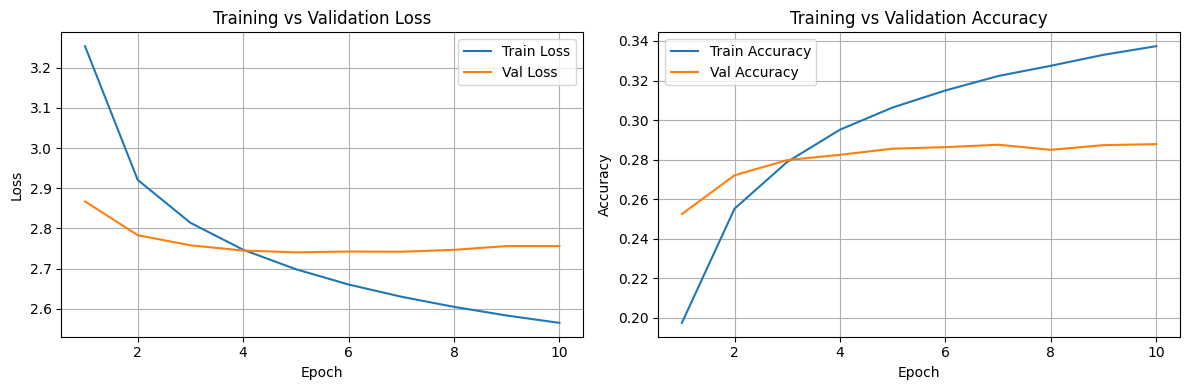

In [21]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 4))

# ---- Loss curves ----
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

# ---- Accuracy curves ----
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [22]:
# === Test set evaluation ===
model.eval()

with torch.no_grad():
    test_loss, test_acc = run_epoch(
        test_loader, model, criterion, optimizer=None
    )

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

print("\nReminder: majority baseline test accuracy was about 0.0389")

Test loss: 2.8995
Test accuracy: 0.2735

Reminder: majority baseline test accuracy was about 0.0389


In [23]:
def train_config(
    name,
    embed_dim=64,
    hidden_dim=128,
    num_layers=1,
    dropout=0.3,
    lr=1e-3,
    weight_decay=1e-5,
    num_epochs=8,
):
    """
    Train a new MusicGRUModel with the given hyperparameters.
    Returns: (history_dict, best_val_acc)
    """
    print(f"\n=== Training config: {name} ===")
    print(f"embed_dim={embed_dim}, hidden_dim={hidden_dim}, "
          f"num_layers={num_layers}, dropout={dropout}, lr={lr}")

    # Fresh model & optimizer for this config
    model = MusicGRUModel(
        vocab_size=VOCAB_SIZE,
        embed_dim=embed_dim,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout,
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(), lr=lr, weight_decay=weight_decay
    )

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    best_val_acc = 0.0

    for epoch in range(1, num_epochs + 1):
        start_time = time.time()

        train_loss, train_acc = run_epoch(
            train_loader, model, criterion, optimizer=optimizer
        )

        with torch.no_grad():
            val_loss, val_acc = run_epoch(
                val_loader, model, criterion, optimizer=None
            )

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc

        elapsed = time.time() - start_time
        print(
            f"Epoch {epoch:02d}/{num_epochs} - {elapsed:.1f}s | "
            f"train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f} | "
            f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}"
        )

    history = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accuracies": train_accuracies,
        "val_accuracies": val_accuracies,
    }

    print(f"Best val accuracy for {name}: {best_val_acc:.4f}")
    return history, best_val_acc


In [ ]:
# Config A: current (smaller) model
history_a, best_val_acc_a = train_config(
    name="small_GRU",
    embed_dim=64,
    hidden_dim=128,
    num_layers=1,
    dropout=0.3,
    lr=1e-3,
    num_epochs=6,      # fewer epochs just for comparison
)

# Config B: a larger model
history_b, best_val_acc_b = train_config(
    name="bigger_GRU",
    embed_dim=128,
    hidden_dim=256,
    num_layers=1,
    dropout=0.3,
    lr=1e-3,
    num_epochs=6,
)

print("\nSummary of configs:")
print(f"small_GRU  best val acc: {best_val_acc_a:.4f}")
print(f"bigger_GRU best val acc: {best_val_acc_b:.4f}")



=== Training config: small_GRU ===
embed_dim=64, hidden_dim=128, num_layers=1, dropout=0.3, lr=0.001
Epoch 01/6 - 18.9s | train_loss: 3.2597, train_acc: 0.1946 | val_loss: 2.8675, val_acc: 0.2556
Epoch 02/6 - 18.1s | train_loss: 2.9272, train_acc: 0.2539 | val_loss: 2.7942, val_acc: 0.2696
Epoch 03/6 - 18.5s | train_loss: 2.8231, train_acc: 0.2767 | val_loss: 2.7676, val_acc: 0.2766
Epoch 04/6 - 17.9s | train_loss: 2.7574, train_acc: 0.2915 | val_loss: 2.7554, val_acc: 0.2817
Epoch 05/6 - 18.5s | train_loss: 2.7102, train_acc: 0.3024 | val_loss: 2.7545, val_acc: 0.2862
Epoch 06/6 - 17.9s | train_loss: 2.6723, train_acc: 0.3111 | val_loss: 2.7519, val_acc: 0.2873
Best val accuracy for small_GRU: 0.2873

=== Training config: bigger_GRU ===
embed_dim=128, hidden_dim=256, num_layers=1, dropout=0.3, lr=0.001
Epoch 01/6 - 31.7s | train_loss: 3.0882, train_acc: 0.2277 | val_loss: 2.7816, val_acc: 0.2731
Epoch 02/6 - 31.8s | train_loss: 2.7497, train_acc: 0.2962 | val_loss: 2.7313, val_acc: 0

In [ ]:
import os
os.makedirs("models", exist_ok=True)

MODEL_PATH = "models/music_gru_small_epoch10.pth"

checkpoint = {
    "state_dict": model.state_dict(),
    "vocab": vocab,
    "seq_len": SEQ_LEN,
    "embed_dim": 64,    # update if you changed
    "hidden_dim": 128,  # update if you changed
    "num_layers": 1,
    "dropout": 0.3,
}

torch.save(checkpoint, MODEL_PATH)
print(f"Saved model checkpoint to {MODEL_PATH}")


: 